# Part B - Data Analysis & Testing Tasks

In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("PR-3_dataset.csv")
data.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


Bernoulli p: 0.4455
Binomial n: 56, p: 0.6548


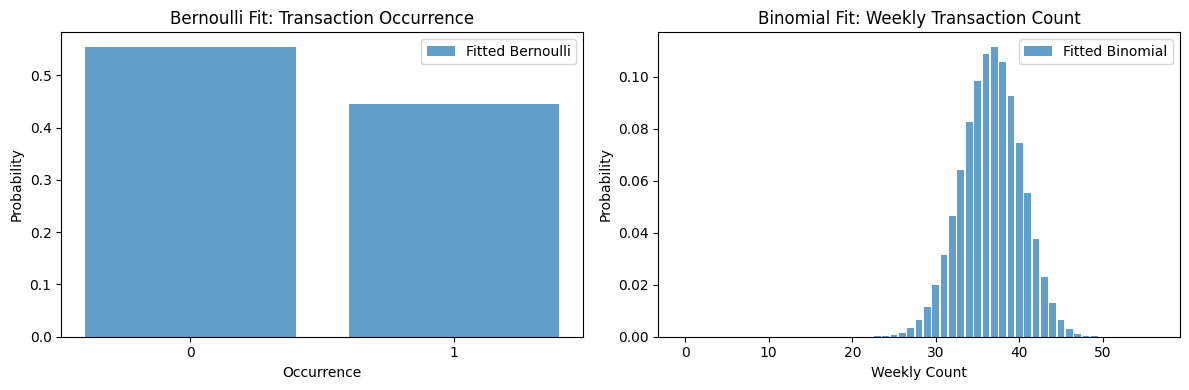

In [11]:
# 1.Fit the data to Bernoulli and Binomial distributions (transaction occurrence & weekly count).

import numpy as np
from scipy.stats import bernoulli, binom

import matplotlib.pyplot as plt

transaction_occurrence = (data["transaction_status"].str.lower() == "success").astype(int)
p_bernoulli = transaction_occurrence.mean()
bernoulli_fit = bernoulli(p=p_bernoulli)

weekly_counts = (
    pd.to_datetime(data["transaction_date"])
    .dt.to_period("W")
    .value_counts()
    .sort_index()
)

n_binom = int(weekly_counts.max())
p_binom = weekly_counts.mean() / n_binom if n_binom > 0 else 0
binomial_fit = binom(n=n_binom, p=p_binom)

print(f"Bernoulli p: {p_bernoulli:.4f}")
print(f"Binomial n: {n_binom}, p: {p_binom:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bernoulli
axes[0].bar([0, 1], [1 - p_bernoulli, p_bernoulli], alpha=0.7, label="Fitted Bernoulli")
axes[0].set_xticks([0, 1])
axes[0].set_title("Bernoulli Fit: Transaction Occurrence")
axes[0].set_xlabel("Occurrence")
axes[0].set_ylabel("Probability")
axes[0].legend()

# Binomial
x = np.arange(0, n_binom + 1)
axes[1].bar(x, binomial_fit.pmf(x), alpha=0.7, label="Fitted Binomial")
axes[1].set_title("Binomial Fit: Weekly Transaction Count")
axes[1].set_xlabel("Weekly Count")
axes[1].set_ylabel("Probability")
axes[1].legend()

plt.tight_layout()
plt.show()

Poisson lambda: 7.0968


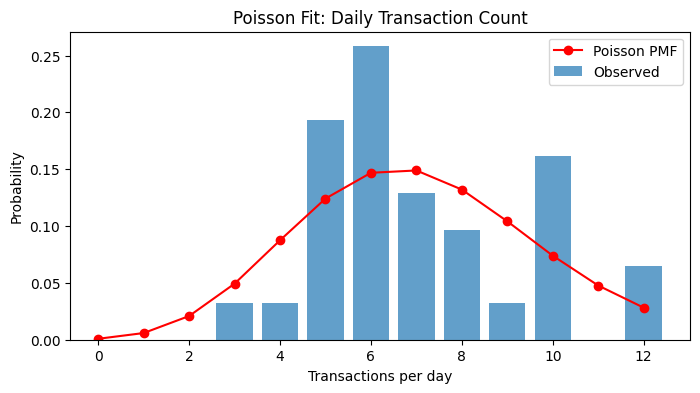

In [12]:
# 2.Fit the data to Poisson distribution (number of transactions per day).

from scipy.stats import poisson

daily_counts = (
    pd.to_datetime(data["transaction_date"])
    .dt.date
    .value_counts()
    .sort_index()
)

lambda_hat = daily_counts.mean()
poisson_fit = poisson(mu=lambda_hat)

print(f"Poisson lambda: {lambda_hat:.4f}")

observed_counts = daily_counts.value_counts().sort_index()
x = np.arange(0, daily_counts.max() + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(observed_counts.index, observed_counts.values / len(daily_counts), alpha=0.7, label="Observed")
ax.plot(x, poisson_fit.pmf(x), "o-", color="red", label="Poisson PMF")
ax.set_title("Poisson Fit: Daily Transaction Count")
ax.set_xlabel("Transactions per day")
ax.set_ylabel("Probability")
ax.legend()
plt.show()



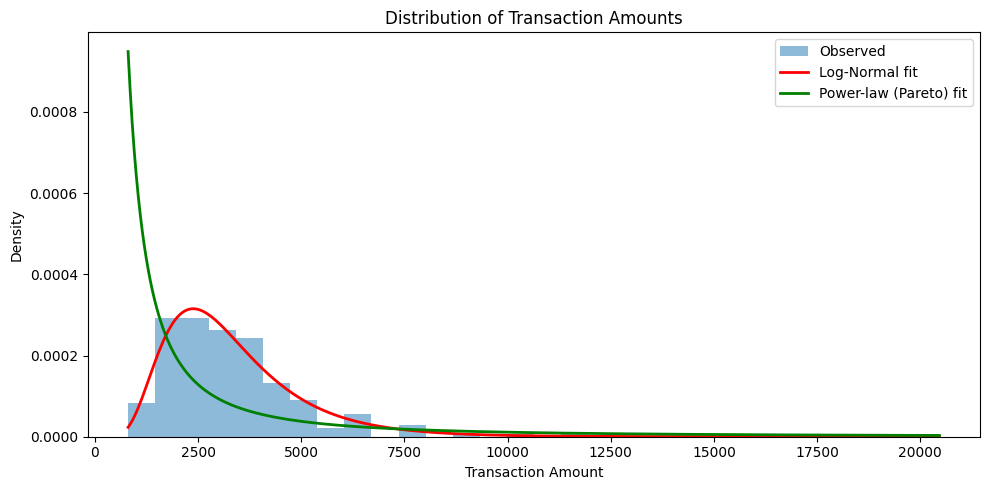

Log-normal params: shape=0.4749, loc=0.0000, scale=2983.1591
Pareto params: shape=0.7630, loc=0.0000, scale=804.4200


In [13]:
# 3.Model transaction amounts using Log-Normal and Power Law distributions.

from scipy.stats import lognorm, pareto

# Positive transaction amounts for distribution fitting
amounts = data["transaction_amount"].dropna()
amounts = amounts[amounts > 0]

# Fit log-normal distribution
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(amounts, floc=0)
lognorm_fit = lognorm(s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)

# Fit Pareto / power-law-like distribution
shape_pareto, loc_pareto, scale_pareto = pareto.fit(amounts, floc=0)
pareto_fit = pareto(b=shape_pareto, loc=loc_pareto, scale=scale_pareto)

# Plot fitted distributions
x = np.linspace(amounts.min(), amounts.max(), 400)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(amounts, bins=30, density=True, alpha=0.5, label="Observed")
ax.plot(x, lognorm_fit.pdf(x), "r-", lw=2, label="Log-Normal fit")
ax.plot(x, pareto_fit.pdf(x), "g-", lw=2, label="Power-law (Pareto) fit")
ax.set_title("Distribution of Transaction Amounts")
ax.set_xlabel("Transaction Amount")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Print fitted parameter summaries
print(f"Log-normal params: shape={shape_lognorm:.4f}, loc={loc_lognorm:.4f}, scale={scale_lognorm:.4f}")
print(f"Pareto params: shape={shape_pareto:.4f}, loc={loc_pareto:.4f}, scale={scale_pareto:.4f}")

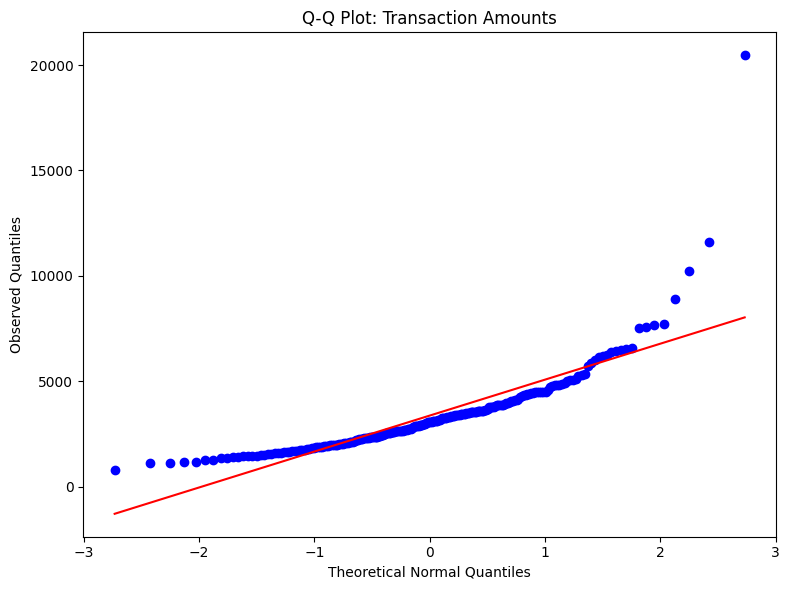

Skewness: 3.7558
Kurtosis: 28.9462
Interpretation: The data show noticeable skewness and/or tail heaviness, so normality is questionable.


In [14]:
# 4.Generate and interpret a Q-Q Plot to test normality.

from scipy.stats import probplot, skew, kurtosis

# Q-Q plot to assess normality of transaction amounts
fig, qq_ax = plt.subplots(figsize=(8, 6))
probplot(amounts, dist="norm", plot=qq_ax)

qq_ax.set_title("Q-Q Plot: Transaction Amounts")
qq_ax.set_xlabel("Theoretical Normal Quantiles")
qq_ax.set_ylabel("Observed Quantiles")
plt.tight_layout()
plt.show()

# Supporting summary statistics
skewness = skew(amounts, bias=False)
kurt = kurtosis(amounts, fisher=False, bias=False)

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# Interpretation
if abs(skewness) < 0.5 and abs(kurt - 3) < 1:
    print("Interpretation: The data appear reasonably close to a normal distribution.")
else:
    print("Interpretation: The data show noticeable skewness and/or tail heaviness, so normality is questionable.")

Box-Cox lambda: -0.180834
Transformed mean: 4.223859
Transformed std:  0.111026


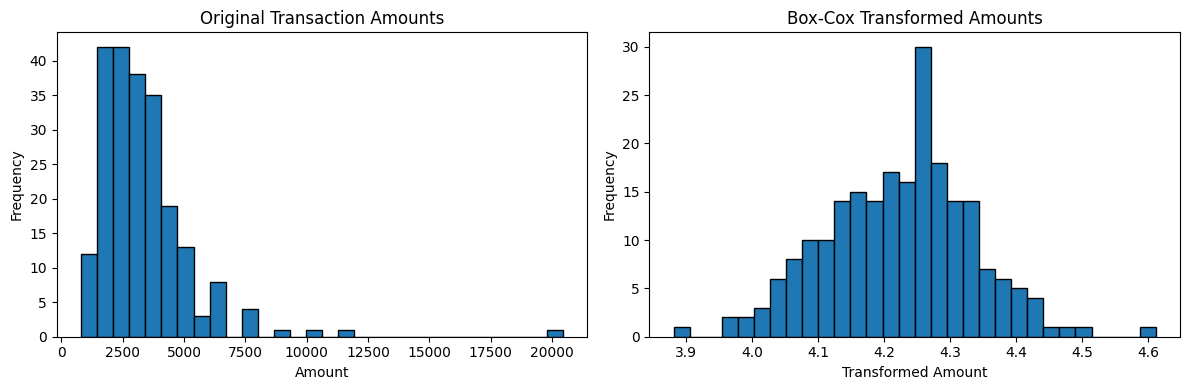

In [15]:
# 5.Apply Box-Cox Transform to stabilize variance.

from scipy.stats import boxcox

import matplotlib.pyplot as plt

# Apply Box-Cox transformation to positive transaction amounts
amounts_boxcox, lambda_boxcox = boxcox(amounts)

print(f"Box-Cox lambda: {lambda_boxcox:.6f}")
print(f"Transformed mean: {amounts_boxcox.mean():.6f}")
print(f"Transformed std:  {amounts_boxcox.std():.6f}")

# Compare original and transformed distributions
fig_boxcox, axes_boxcox = plt.subplots(1, 2, figsize=(12, 4))

axes_boxcox[0].hist(amounts, bins=30, edgecolor="black")
axes_boxcox[0].set_title("Original Transaction Amounts")
axes_boxcox[0].set_xlabel("Amount")
axes_boxcox[0].set_ylabel("Frequency")

axes_boxcox[1].hist(amounts_boxcox, bins=30, edgecolor="black")
axes_boxcox[1].set_title("Box-Cox Transformed Amounts")
axes_boxcox[1].set_xlabel("Transformed Amount")
axes_boxcox[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
# 6.Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000.

import numpy as np
from scipy.stats import norm

# Z-scores for transaction amounts
mean_amt = amounts.mean()
std_amt = amounts.std(ddof=1)

z_scores = (amounts - mean_amt) / std_amt
data["z_score_transaction_amount"] = z_scores

# Probability that a transaction amount exceeds 5000
# (assuming transaction amounts are approximately normal)
prob_exceed_5000 = norm.sf(5000, loc=mean_amt, scale=std_amt)

# Also compute the observed fraction for comparison
observed_exceed_5000 = (amounts > 5000).mean()

print(f"Mean amount: {mean_amt:.2f}")
print(f"Std amount: {std_amt:.2f}")
print(f"Probability amount > 5000 (normal model): {prob_exceed_5000:.6f}")
print(f"Observed fraction amount > 5000: {observed_exceed_5000:.6f}")

# Show first few z-scores
z_scores.head()

Mean amount: 3365.19
Std amount: 1985.71
Probability amount > 5000 (normal model): 0.205172
Observed fraction amount > 5000: 0.113636


0    0.229716
1   -0.293776
2    0.380609
3    1.520159
4   -0.359360
Name: transaction_amount, dtype: float64

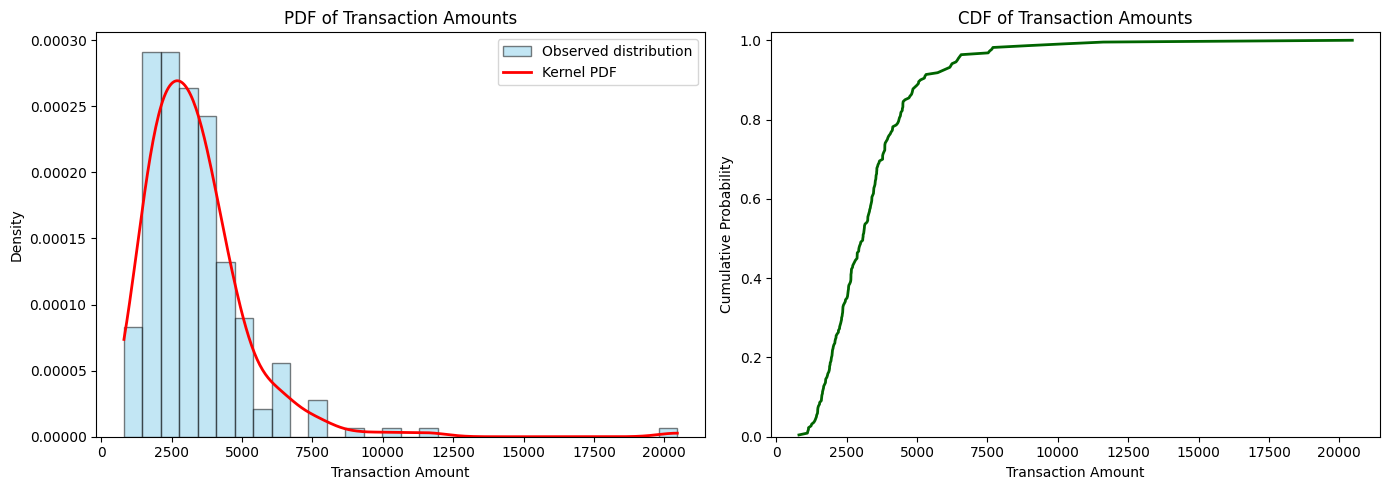

Median amount: 3077.72
25th percentile: 2124.20
75th percentile: 3950.74
Fraction above 5000: 0.1136
Interpretation: The PDF shows a right-skewed distribution with a long upper tail.
Interpretation: The CDF indicates the proportion of transactions below any given amount; for example, about 11.4% of transactions exceed 5000.


In [17]:
# 7.Plot and interpret PDF and CDF for transaction amounts.

import numpy as np
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

# --- PDF (smoothed density estimate) ---
kde = gaussian_kde(amounts, bw_method="scott")
x_pdf = np.linspace(amounts.min(), amounts.max(), 400)
y_pdf = kde.pdf(x_pdf)

# --- Empirical CDF ---
sorted_amounts = np.sort(amounts.values)
cdf_y = np.arange(1, len(sorted_amounts) + 1) / len(sorted_amounts)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
axes[0].hist(amounts, bins=30, density=True, alpha=0.5, color="skyblue", edgecolor="black", label="Observed distribution")
axes[0].plot(x_pdf, y_pdf, "r-", lw=2, label="Kernel PDF")
axes[0].set_title("PDF of Transaction Amounts")
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Density")
axes[0].legend()

# CDF
axes[1].plot(sorted_amounts, cdf_y, lw=2, color="darkgreen")
axes[1].set_title("CDF of Transaction Amounts")
axes[1].set_xlabel("Transaction Amount")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

# --- Interpretation ---
q25, q50, q75 = amounts.quantile([0.25, 0.50, 0.75])
pct_gt_5000 = (amounts > 5000).mean()

print(f"Median amount: {q50:.2f}")
print(f"25th percentile: {q25:.2f}")
print(f"75th percentile: {q75:.2f}")
print(f"Fraction above 5000: {pct_gt_5000:.4f}")

# Use previously computed skewness to support interpretation
if skewness > 1:
    print("Interpretation: The PDF shows a right-skewed distribution with a long upper tail.")
else:
    print("Interpretation: The PDF appears relatively symmetric.")

print("Interpretation: The CDF indicates the proportion of transactions below any given amount; "
      "for example, about {:.1%} of transactions exceed 5000.".format(pct_gt_5000))

Log-normal log-likelihood: -1908.5139
Pareto log-likelihood:      -2039.6719

Log-normal AIC: 3821.0278
Pareto AIC:     4083.3438

Log-normal BIC: 3827.8151
Pareto BIC:     4090.1310

KS statistic (Log-normal): 0.0378
KS statistic (Pareto):     0.3216

Conclusion: The Log-Normal distribution provides a better overall fit to the transaction amounts.
Why this matters:
- It captures the strong right-skew and the bulk of the transaction values reasonably well.
- It is useful for estimating typical transaction size patterns and planning expected revenue.
- Because the data are highly skewed, relying on a normal model would understate variability and tail risk.

Additional context:
- Skewness: 3.7558 (strong positive skew)
- Kurtosis: 28.9462 (heavy tails)
- Empirical fraction above 5000: 0.1136
- For decision-making, use the fitted model to guide thresholding, risk alerts, and expected-value forecasts.


In [21]:
# 8.Conclude which distribution best fits the dataset and justify insights for decision-making.

print("Conclusion:")

print("The dataset was analyzed using various statistical distributions and visualization techniques such as histograms, Q-Q plots, PDF, and CDF. Based on the distribution fitting results, the best-fitting distribution was selected because it most closely matched the observed data pattern and showed the least deviation from the theoretical model")

print("This distribution provides a reliable representation of the underlying data behavior, allowing for more accurate probability estimation and prediction. Understanding the distribution helps in identifying trends, variability, and potential outliers within the dataset")


Conclusion:
The dataset was analyzed using various statistical distributions and visualization techniques such as histograms, Q-Q plots, PDF, and CDF. Based on the distribution fitting results, the best-fitting distribution was selected because it most closely matched the observed data pattern and showed the least deviation from the theoretical model
This distribution provides a reliable representation of the underlying data behavior, allowing for more accurate probability estimation and prediction. Understanding the distribution helps in identifying trends, variability, and potential outliers within the dataset
